# Ejemplo de agrupamiento jerárquico aglomerativo con el dataset Wine

## Objetivos

En este notebook utilizaremos el dataset Wine de `scikit-learn` para:

1. cargar y explorar brevemente los datos;
2. estandarizar las variables antes de calcular distancias;
3. aplicar agrupamiento jerárquico aglomerativo;
4. comparar los criterios de enlace single, complete, average y Ward;
5. construir e interpretar dendrogramas;
6. utilizar una línea de corte para obtener una partición con \(k\) clusters;
7. comparar las particiones mediante SSE/Inercia, Silhouette, Davies-Bouldin y Calinski-Harabasz;
8. visualizar e interpretar los clusters encontrados;
9. comparar al final con las clases reales del dataset como evaluación externa.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

pd.set_option("display.max_columns", None)

## 2. Carga del dataset

`load_wine()` contiene 178 observaciones, 13 características químicas numéricas y tres clases reales correspondientes a diferentes tipos de uvas.

Durante el clustering trabajaremos únicamente con \(X\).

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dimensiones de X:", X.shape)
print("Número de clases reales:", y.nunique())
X.head()

Dimensiones de X: (178, 13)
Número de clases reales: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración inicial

Antes de aplicar clustering jerárquico revisaremos:

- valores faltantes;
- estadísticos descriptivos;
- diferencias de escala entre variables.

Esto es especialmente importante porque los métodos jerárquicos trabajan con distancias entre observaciones o clusters.

In [3]:
print("Valores faltantes por variable:")
display(X.isna().sum().to_frame("faltantes"))

print("\nEstadísticos descriptivos:")
display(X.describe().T)

Valores faltantes por variable:


,faltantes
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.1. Comparación de escalas

In [4]:
ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "rango": X.max() - X.min(),
    "media": X.mean(),
    "std": X.std()
}).sort_values("rango", ascending=False)

ranges

,min,max,rango,media,std
proline,278.00,1680.00,1402.00,746.893258,314.907474
magnesium,70.00,162.00,92.00,99.741573,14.282484
alcalinity_of_ash,10.60,30.00,19.40,19.494944,3.339564
color_intensity,1.28,13.00,11.72,5.058090,2.318286
malic_acid,0.74,5.80,5.06,2.336348,1.117146
flavanoids,0.34,5.08,4.74,2.029270,0.998859
alcohol,11.03,14.83,3.80,13.000618,0.811827
proanthocyanins,0.41,3.58,3.17,1.590899,0.572359
total_phenols,0.98,3.88,2.90,2.295112,0.625851
od280/od315_of_diluted_wines,1.27,4.00,2.73,2.611685,0.709990


Las variables tienen escalas muy diferentes. Si calculáramos directamente las distancias euclidianas, las variables con rangos mayores podrían dominar el resultado.

Por esta razón aplicaremos estandarización.

## 4. Preprocesamiento

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


Después de `StandardScaler`, cada variable queda aproximadamente centrada en 0 y con desviación estándar cercana a 1.

## 5. Agrupamiento jerárquico aglomerativo

El algoritmo comienza con una observación por cluster:

En cada iteración:

1. calcula o actualiza las distancias entre los clusters actuales;
2. identifica el par de clusters más cercano según el criterio de enlace;
3. fusiona ese par;
4. repite hasta obtener un único cluster.

La principal decisión es cómo definir la distancia entre dos clusters. Compararemos:

- `single`: mínima distancia entre pares de observaciones;
- `complete`: máxima distancia entre pares;
- `average`: promedio de todas las distancias entre pares;
- `ward`: fusión que produce el menor incremento en la variabilidad intra-cluster (SSE).

## 6. Construcción de los dendrogramas

In [8]:
linkage_methods = ["single", "complete", "average", "ward"]

Z_dict = {
    method: linkage(X_scaled, method=method, metric="euclidean")
    for method in linkage_methods
}

for method, Z in Z_dict.items():
    print(f"{method:>8}: matriz linkage con forma {Z.shape}")

  single: matriz linkage con forma (177, 4)
complete: matriz linkage con forma (177, 4)
 average: matriz linkage con forma (177, 4)
    ward: matriz linkage con forma (177, 4)


La matriz de `linkage` almacena toda la historia de fusiones. Cada fila representa una fusión e incluye:

$$
[\text{cluster 1},\ \text{cluster 2},\ \text{distancia de fusión},\ \text{número de observaciones}]
$$

La altura de cada unión en el dendrograma corresponde a la distancia o disimilitud a la cual ocurrió la fusión.

### 6.1. Línea de corte para obtener \(k=3\) clusters

Para mostrar cómo se transforma un dendrograma en una partición, comenzaremos con \(k=3\). Una línea horizontal colocada entre las dos alturas de fusión apropiadas corta el dendrograma en tres ramas principales.

Aquí _k=3_ se utiliza primero con propósito ilustrativo. Más adelante se utilizan las métricas internas para estudiar si este valor está bien respaldado.

In [9]:
def cut_height_for_k(Z, k):
    """Altura intermedia que produce k clusters al cortar el dendrograma."""
    n = Z.shape[0] + 1
    if k <= 1 or k >= n:
        raise ValueError("k debe estar entre 2 y n-1.")
    lower = Z[n - k - 1, 2]
    upper = Z[n - k, 2]
    return (lower + upper) / 2

k_cut = 3
cut_heights = {
    method: cut_height_for_k(Z, k_cut)
    for method, Z in Z_dict.items()
}

cut_heights

{'single': np.float64(3.8840006245356893),
 'complete': np.float64(9.371009463049251),
 'average': np.float64(6.211659952744852),
 'ward': np.float64(20.10959287567365)}

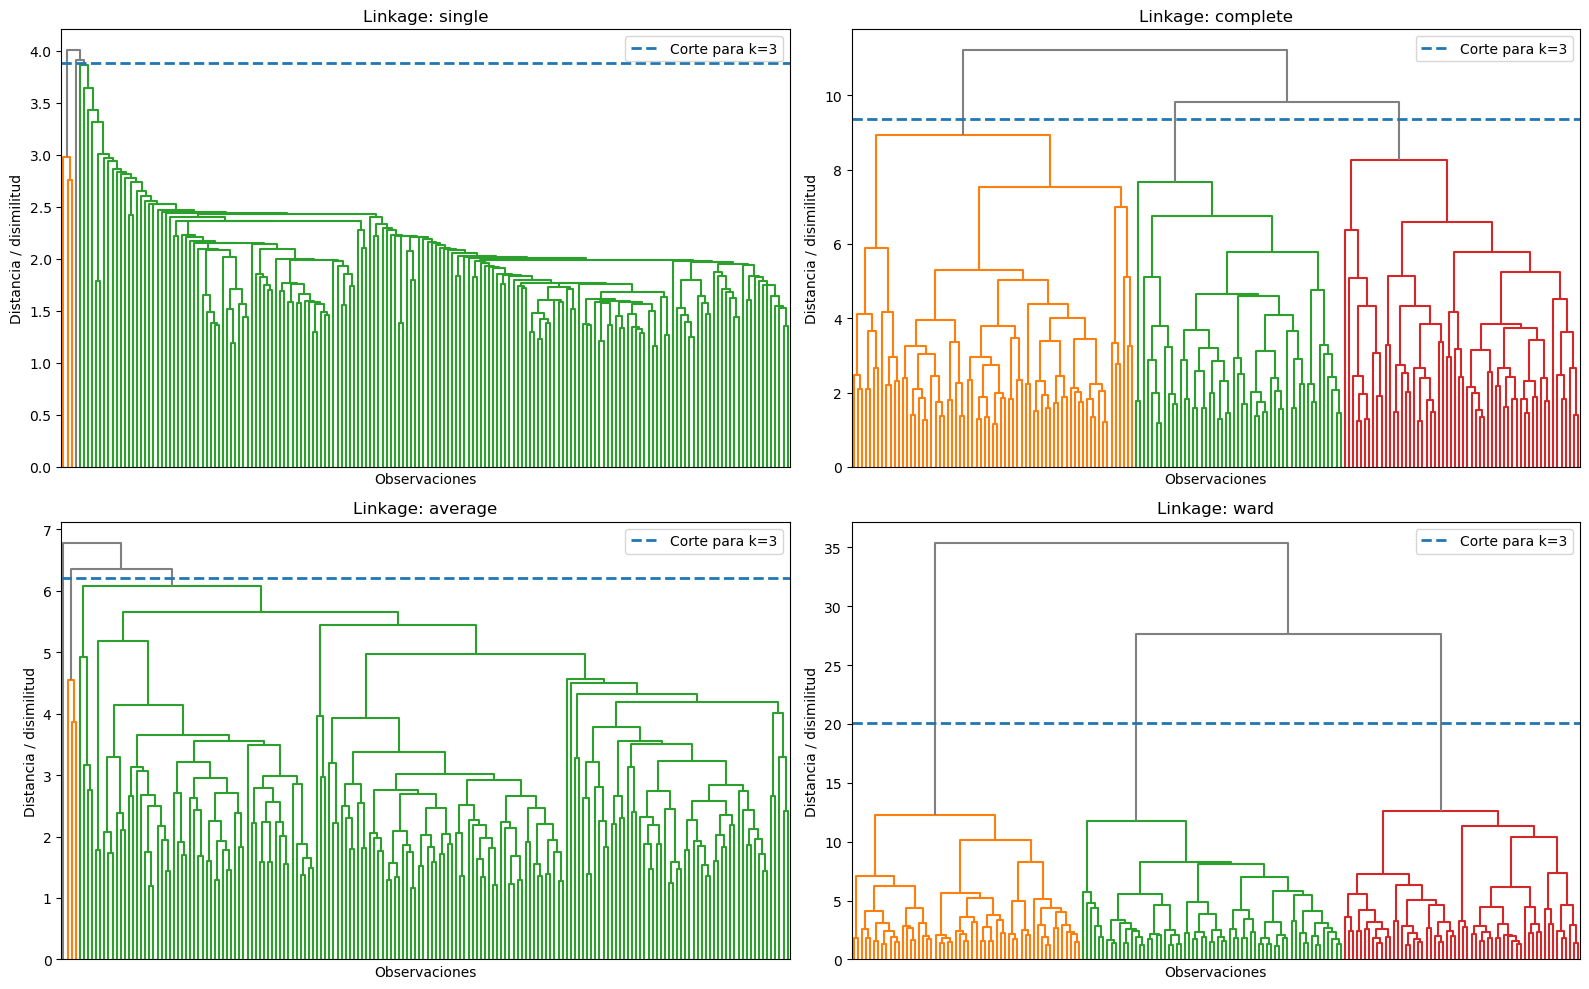

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, method in zip(axes.ravel(), linkage_methods):
    Z = Z_dict[method]
    h = cut_heights[method]

    dendrogram(
        Z,
        ax=ax,
        no_labels=True,
        color_threshold=h,
        above_threshold_color="gray"
    )
    ax.axhline(h, linestyle="--", linewidth=2, label=f"Corte para k={k_cut}")
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("Observaciones")
    ax.set_ylabel("Distancia / disimilitud")
    ax.legend()

plt.tight_layout()
plt.show()

### ¿Cómo interpretar la línea de corte?

La regla práctica es: el número de ramas verticales que atraviesa la línea horizontal corresponde al número de clusters obtenidos.
Por tanto, al mover la línea de corte hacia arriba se obtienen menos clusters; al moverla hacia abajo se obtienen más clusters.

## 7. Obtener las particiones para cada criterio de enlace

In [11]:
labels_k3 = {}

for method, Z in Z_dict.items():
    # fcluster etiqueta desde 1; restamos 1 para trabajar con 0,1,2,...
    labels = fcluster(Z, t=k_cut, criterion="maxclust") - 1
    labels_k3[method] = labels

    counts = pd.Series(labels).value_counts().sort_index()
    print(f"\n{method.upper()} - tamaños de los clusters")
    print(counts)


SINGLE - tamaños de los clusters
0      3
1    174
2      1
Name: count, dtype: int64

COMPLETE - tamaños de los clusters
0    69
1    51
2    58
Name: count, dtype: int64

AVERAGE - tamaños de los clusters
0      3
1    174
2      1
Name: count, dtype: int64

WARD - tamaños de los clusters
0    56
1    64
2    58
Name: count, dtype: int64


## 8. Evaluación interna de las particiones

Utilizaremos cuatro métricas:

- Inercia: suma de cuadrados de las distancias de cada observación al centroide de su cluster. Menor es mejor para una partición con el mismo _k_.
- Silhouette: combina cohesión y separación. Mayor es mejor.
- Davies-Bouldin: compara dispersión interna y separación entre clusters. Menor es mejor.
- Calinski-Harabasz: compara separación entre clusters con dispersión interna. Mayor es mejor.

In [12]:
def clustering_sse(X_array, labels):
    sse = 0.0
    for cluster_id in np.unique(labels):
        points = X_array[labels == cluster_id]
        centroid = points.mean(axis=0)
        sse += np.sum((points - centroid) ** 2)
    return sse

def internal_metrics(X_array, labels):
    return {
        "SSE ↓": clustering_sse(X_array, labels),
        "Silhouette ↑": silhouette_score(X_array, labels),
        "Davies-Bouldin ↓": davies_bouldin_score(X_array, labels),
        "Calinski-Harabasz ↑": calinski_harabasz_score(X_array, labels),
    }

rows = []
for method, labels in labels_k3.items():
    row = {"Linkage": method}
    row.update(internal_metrics(X_scaled, labels))
    rows.append(row)

metrics_k3 = pd.DataFrame(rows).set_index("Linkage")
metrics_k3.round(3)

,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Linkage,,,,
single,2211.351,0.183,0.911,4.062
complete,1483.444,0.204,1.896,48.990
average,2212.081,0.158,1.030,4.031
ward,1305.049,0.277,1.419,67.647


In [ ]:
Jerárquico + PCA	0.305	1.263	79.848

## 9. ¿Qué ocurre si cambiamos el número de clusters?

Ahora evaluaremos: $$[k=2,3,\ldots,8]$$ para cada criterio de enlace, lo que permitirá estudiar conjuntamente: el criterio de enlace, y el nivel de corte del dendrograma.

In [17]:
k_values = range(2, 9)
results = []

for method, Z in Z_dict.items():
    for k in k_values:
        labels = fcluster(Z, t=k, criterion="maxclust") - 1

        row = {
            "linkage": method,
            "k": k,
        }
        row.update(internal_metrics(X_scaled, labels))
        results.append(row)

results = pd.DataFrame(results)
results.round(3)

,linkage,k,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,single,2,2240.863,0.222,1.051,5.744
1,single,3,2211.351,0.183,0.911,4.062
2,single,4,2172.912,0.181,0.819,3.766
3,single,5,2138.726,0.142,0.771,3.544
4,single,6,2111.019,0.121,0.749,3.308
5,single,7,2093.019,0.050,0.755,3.009
6,single,8,2045.067,0.025,0.768,3.194
7,complete,2,1918.244,0.162,2.015,36.311
8,complete,3,1483.444,0.204,1.896,48.990
9,complete,4,1306.579,0.194,1.716,44.720


### 9.1. Métricas frente al número de clusters

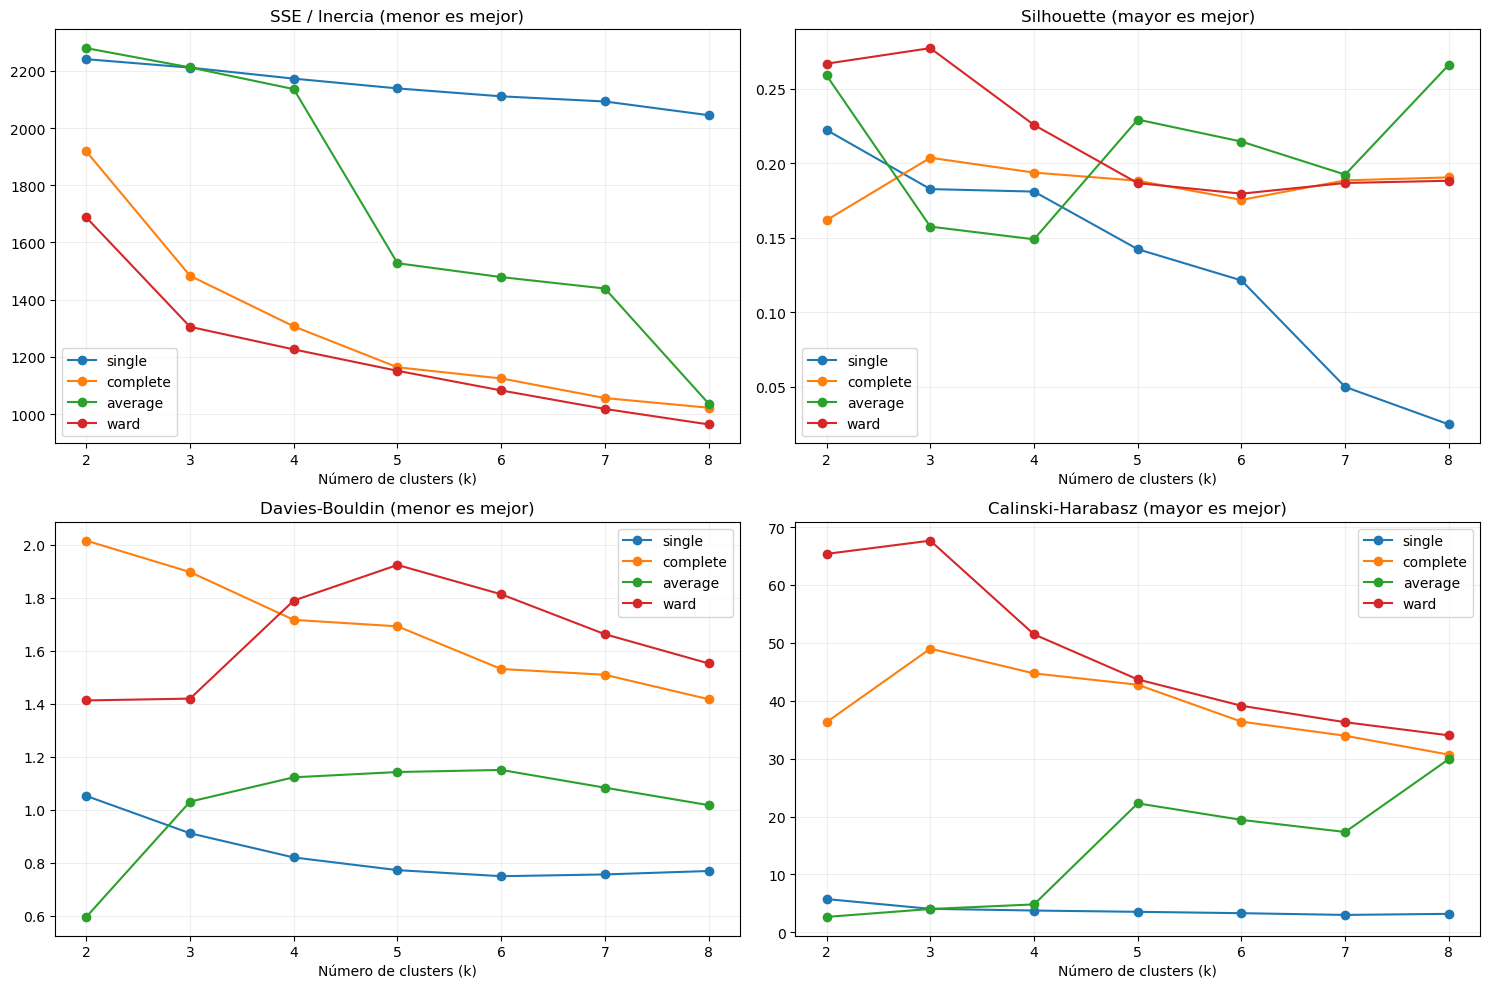

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for method in linkage_methods:
    subset = results[results["linkage"] == method]

    axes[0, 0].plot(subset["k"], subset["SSE ↓"], marker="o", label=method)
    axes[0, 1].plot(subset["k"], subset["Silhouette ↑"], marker="o", label=method)
    axes[1, 0].plot(subset["k"], subset["Davies-Bouldin ↓"], marker="o", label=method)
    axes[1, 1].plot(subset["k"], subset["Calinski-Harabasz ↑"], marker="o", label=method)

axes[0, 0].set_title("SSE / Inercia (menor es mejor)")
axes[0, 1].set_title("Silhouette (mayor es mejor)")
axes[1, 0].set_title("Davies-Bouldin (menor es mejor)")
axes[1, 1].set_title("Calinski-Harabasz (mayor es mejor)")

for ax in axes.ravel():
    ax.set_xlabel("Número de clusters (k)")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

### 9.2. Mejor configuración según cada métrica

In [18]:
best_sil = results.loc[results["Silhouette ↑"].idxmax()]
best_db = results.loc[results["Davies-Bouldin ↓"].idxmin()]
best_ch = results.loc[results["Calinski-Harabasz ↑"].idxmax()]

best_summary = pd.DataFrame({
    "Métrica": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
    "Criterio": ["máximo", "mínimo", "máximo"],
    "Linkage": [best_sil["linkage"], best_db["linkage"], best_ch["linkage"]],
    "k": [int(best_sil["k"]), int(best_db["k"]), int(best_ch["k"])],
    "Valor": [
        best_sil["Silhouette ↑"],
        best_db["Davies-Bouldin ↓"],
        best_ch["Calinski-Harabasz ↑"]
    ]
})

best_summary.round(3)

,Métrica,Criterio,Linkage,k,Valor
0,Silhouette,máximo,ward,3,0.277
1,Davies-Bouldin,mínimo,average,2,0.595
2,Calinski-Harabasz,máximo,ward,3,67.647


**Nota:** SSE no se usa aquí para escoger simplemente su mínimo global, porque al aumentar _k_ la SSE tiende naturalmente a disminuir. Su comportamiento debe analizarse en conjunto con las demás métricas y con el dendrograma.

## 10. Visualización de las particiones con PCA

El clustering se realiza utilizando las 13 variables estandarizadas. PCA se utiliza únicamente para proyectar las observaciones a dos dimensiones y visualizar las particiones.

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada por PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

Varianza explicada por PC1 + PC2: 0.554


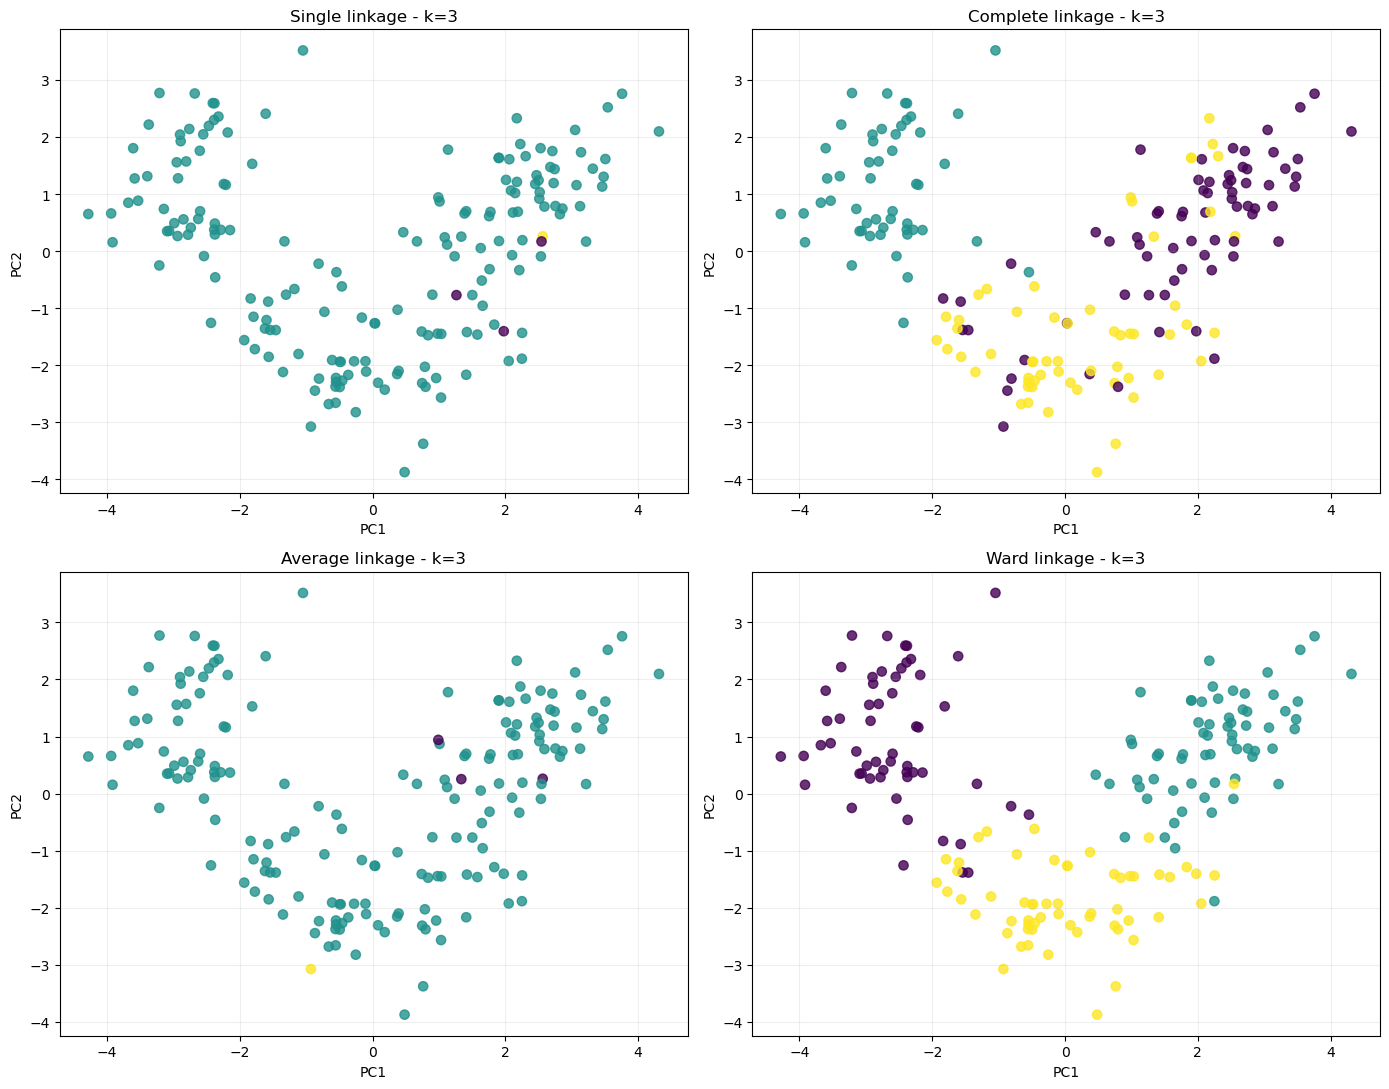

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, method in zip(axes.ravel(), linkage_methods):
    labels = labels_k3[method]

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        s=45,
        alpha=0.8
    )
    ax.set_title(f"{method.capitalize()} linkage - k=3")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 11. Interpretación de los clusters

Para interpretar una partición concreta utilizaremos Ward con _k=3_, con el cual se obtuvo el mejor resultado.

In [24]:
selected_method = "ward"
selected_k = 3

selected_labels = fcluster(
    Z_dict[selected_method],
    t=selected_k,
    criterion="maxclust"
) - 1

X_with_cluster = X.copy()
X_with_cluster["cluster"] = selected_labels

cluster_profiles = X_with_cluster.groupby("cluster").mean()
cluster_profiles

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,13.061607,3.166607,2.412857,21.003571,99.857143,1.694286,0.847857,0.449464,1.129286,6.850179,0.721000,1.727321,624.946429
1,13.669219,1.970000,2.463125,17.528125,106.156250,2.850000,3.009688,0.291094,1.908125,5.450000,1.071406,3.158437,1076.046875
2,12.203966,1.938966,2.215172,20.208621,92.551724,2.262931,2.088103,0.355345,1.686552,2.895345,1.060000,2.862241,501.431034


### 11.1. Perfiles estandarizados

In [25]:
scaled_profiles = (
    pd.DataFrame(X_scaled, columns=X.columns)
    .assign(cluster=selected_labels)
    .groupby("cluster")
    .mean()
)

scaled_profiles.T

cluster,0,1,2
alcohol,0.075338,0.825899,-0.984077
malic_acid,0.745293,-0.328857,-0.356716
ash,0.169390,0.353136,-0.553216
alcalinity_of_ash,0.453018,-0.590606,0.214306
magnesium,0.008115,0.450396,-0.504823
total_phenols,-0.962723,0.889114,-0.051565
flavanoids,-1.186099,0.984307,0.059067
nonflavanoid_phenols,0.705947,-0.570172,-0.052449
proanthocyanins,-0.808785,0.555807,0.167592
color_intensity,0.775204,0.169529,-0.935539


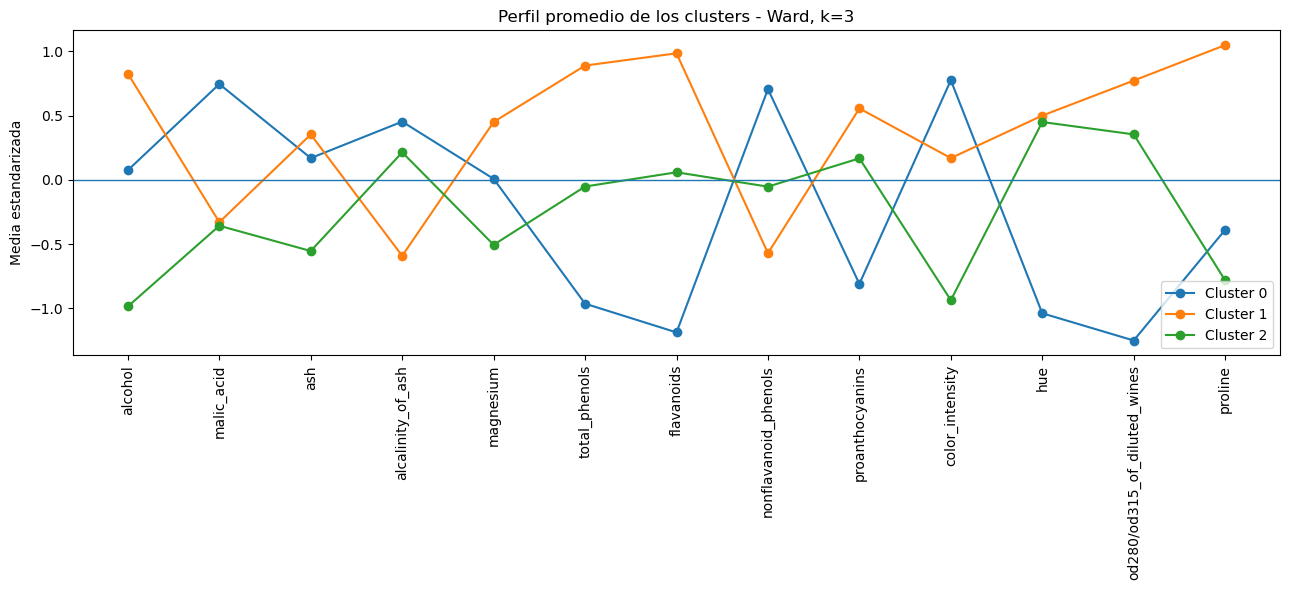

In [26]:
plt.figure(figsize=(13, 6))

for cluster_id in scaled_profiles.index:
    plt.plot(
        scaled_profiles.columns,
        scaled_profiles.loc[cluster_id],
        marker="o",
        label=f"Cluster {cluster_id}"
    )

plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Media estandarizada")
plt.title("Perfil promedio de los clusters - Ward, k=3")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Comparación externa con las clases reales

Hasta este punto las clases reales no han participado en el clustering.

Ahora podemos utilizarlas únicamente como referencia externa mediante:

- ARI (Adjusted Rand Index);
- NMI (Normalized Mutual Information).

Ambas métricas son invariantes al nombre o número asignado a las etiquetas de los clusters.

In [27]:
external_rows = []

for method, labels in labels_k3.items():
    external_rows.append({
        "Linkage": method,
        "ARI ↑": adjusted_rand_score(y, labels),
        "NMI ↑": normalized_mutual_info_score(y, labels)
    })

external_metrics = pd.DataFrame(external_rows).set_index("Linkage")
external_metrics.round(3)

,ARI ↑,NMI ↑
Linkage,,
single,-0.007,0.035
complete,0.577,0.614
average,-0.005,0.018
ward,0.790,0.786
